# 3-coupled SIR model

This notebook will serve as a test environment for the coupled SIR model.

Recall that this first iteration of the coupled model is given by
\begin{align*}
\dot{S}_1 &= -\left(\beta_1 I_1 + \beta_2 I_2 + \beta_3 I_3\right)S_1\\
\dot{I}_1 &= \left(S_1+S_2+S_3\right)\beta_1 I_1 - \gamma_1 I_1\\
\dot{R}_1 &= \gamma_1 I_1\\[2ex]
\dot{S}_2 &= -\left(\beta_1 I_1 + \beta_2 I_2 + \beta_3 I_3\right)S_2\\
\dot{I}_2 &= \left(S_1+S_2+S_3\right)\beta_2 I_2 - \gamma_2 I_2\\
\dot{R}_2 &= \gamma_2 I_2\\[2ex]
\dot{S}_3 &= -\left(\beta_1 I_1 + \beta_2 I_2 + \beta_3 I_3\right)S_3\\
\dot{I}_3 &= \left(S_1+S_2+S_3\right)\beta_3 I_3 - \gamma_3 I_3\\
\dot{R}_3 &= \gamma_3 I_3\\[2ex]
\end{align*}


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fmin
# RHS of system
def SIR_3(t, S, p):
    
    
    s1, i1, r1, s2, i2, r2, s3, i3, r3 = S
    
    return np.array([-(p[0]*i1 + p[1]*i2 + p[2]*i3)*(s1),
                     (s1 + s2 + s3)*p[0]*i1 - p[3]*i1,
                     p[3]*i1,
            
                     -(p[0]*i1 + p[1]*i2 + p[2]*i3)*s2,
                     (s1 + s2 + s3)*p[1]*i2 - p[4]*i2,
                     p[4]*i2,
                     
                     -(p[0]*i1 + p[1]*i2 + p[2]*i3)*s3,
                     (s1 + s2 + s3)*p[2]*i3 - p[5]*i3,
                     p[5]*i3
                     ])



# ODE integration
def RK4_sys(t0,tn,n,y0,diff, args):
    h = abs((tn-t0)/n)
    rows = len(y0)
    
    t = np.linspace(t0,tn,n+1)
    y = np.zeros((rows, n+1))
    
    y[:,0] = y0[:]
    
    for k in range(n):
        
        A = diff(t[k],y[:,k], args)
        B = diff( t[k] + (h/2), y[:,k] + (A*h)/2, args)
        C = diff( t[k]+ (h/2), y[:,k] + (B*h)/2, args)
        D = diff( t[k] + h, y[:,k] + C*h, args)
        y[:,k+1] = y[:,k] + (h/6)*(A + 2*B + 2*C + D)
    return t,y




In [9]:
# setting initial parameters
s10 = 0.9
s20 = 0.8
s30 = 0.7

i10 = 1 - s10
i20 = 1 - s20
i30 = 1 - s30

r10 = 0.
r20 = 0.
r30 = 0.

S0 = np.array([s10, i10, r10, 
               s20, i20, r20,
               s30, i30, r30])

t0 = 0
tf = 50
n = 5000

# infectivity and recovery rates, respectively
beta1 = 0.45
beta2 = 0.10
beta3 = 0.35

gamma1 = 0.95
gamma2 = 0.35
gamma3 = 0.15

p = np.array([beta1, beta2, beta3,
              gamma1, gamma2, gamma3])


t, S = RK4_sys(t0, tf, n, S0, SIR_3, p)

S_total = np.sum(S[0:-1:3, :], axis = 0)/3
I_total = np.sum(S[1:-1:3, :], axis = 0)/3
R_total = np.sum(S[2:9:3, :], axis = 0)/3


S1 = S[0, :]
I1 = S[1, :]
R1 = S[2, :]

S2 = S[3, :]
I2 = S[4, :]
R2 = S[5, :]

S3 = S[6, :]
I3 = S[7, :]
R3 = S[8, :] 


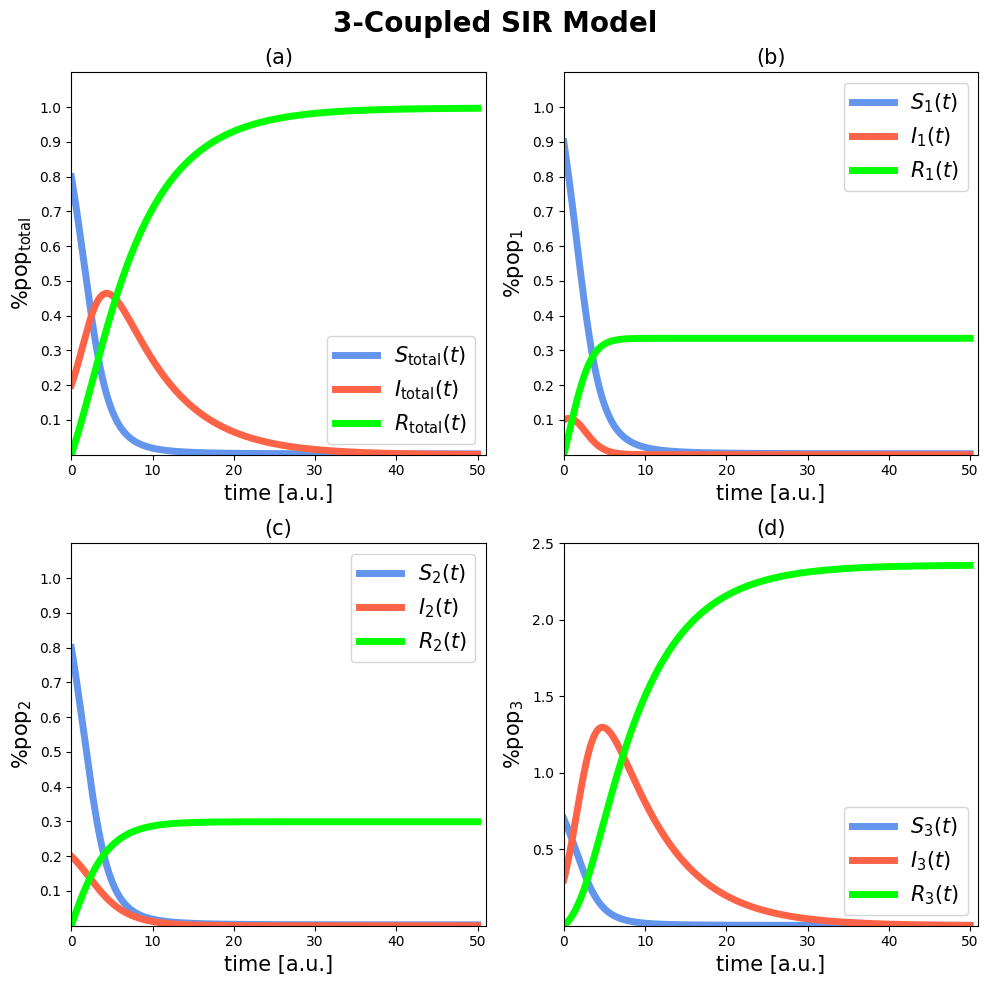

In [10]:
fig1, ax1 = plt.subplots(2,2, figsize = (10,10))
ax1[0,0].plot(t, S_total, color = 'cornflowerblue', label = r'$S_{\text{total}}(t)$', linewidth = 5)
ax1[0,0].plot(t,I_total, color = 'tomato', label = r'$I_{\text{total}}(t)$', linewidth = 5)
ax1[0,0].plot(t,R_total, color = 'lime', label = r'$R_{\text{total}}(t)$', linewidth = 5)
ax1[0,0].legend(fontsize = 15)
ax1[0,0].set_xlabel("time [a.u.]", fontsize = 15)
ax1[0,0].set_ylabel(r"%$\text{pop}_{\text{total}}$", fontsize = 15)
ax1[0,0].set_ylim(0, 1.1)
ax1[0,0].set_xlim(t0, tf+1)
ax1[0,0].set_xticks(np.arange(t0, tf+1, 10))
ax1[0,0].set_yticks(np.arange(0.1, 1.1, 0.1))
ax1[0,0].set_title("(a)", fontsize = 15)

ax1[0,1].plot(t, S1, color = 'cornflowerblue', label = r'$S_{1}(t)$', linewidth = 5)
ax1[0,1].plot(t,I1, color = 'tomato', label = r'$I_{1}(t)$', linewidth = 5)
ax1[0,1].plot(t,R1, color = 'lime', label = r'$R_{1}(t)$', linewidth = 5)
ax1[0,1].legend(fontsize = 15)
ax1[0,1].set_xlabel("time [a.u.]", fontsize = 15)
ax1[0,1].set_ylabel(r"%$\text{pop}_{1}$", fontsize = 15)
ax1[0,1].set_ylim(0, 1.1)
ax1[0,1].set_xlim(t0, tf+1)
ax1[0,1].set_xticks(np.arange(t0, tf+1, 10))
ax1[0,1].set_yticks(np.arange(0.1, 1.1, 0.1))
ax1[0,1].set_title("(b)", fontsize = 15)

ax1[1,0].plot(t, S2, color = 'cornflowerblue', label = r'$S_{2}(t)$', linewidth = 5)
ax1[1,0].plot(t,I2, color = 'tomato', label = r'$I_{2}(t)$', linewidth = 5)
ax1[1,0].plot(t,R2, color = 'lime', label = r'$R_{2}(t)$', linewidth = 5)
ax1[1,0].legend(fontsize = 15)
ax1[1,0].set_xlabel("time [a.u.]", fontsize = 15)
ax1[1,0].set_ylabel(r"%$\text{pop}_{2}$", fontsize = 15)
ax1[1,0].set_ylim(0, 1.1)
ax1[1,0].set_xlim(t0, tf+1)
ax1[1,0].set_xticks(np.arange(t0, tf+1, 10))
ax1[1,0].set_yticks(np.arange(0.1, 1.1, 0.1))
ax1[1,0].set_title("(c)", fontsize = 15)

ax1[1,1].plot(t, S3, color = 'cornflowerblue', label = r'$S_{3}(t)$', linewidth = 5)
ax1[1,1].plot(t, I3, color = 'tomato', label = r'$I_{3}(t)$', linewidth = 5)
ax1[1,1].plot(t, R3, color = 'lime', label = r'$R_{3}(t)$', linewidth = 5)
ax1[1,1].legend(fontsize = 15)
ax1[1,1].set_xlabel("time [a.u.]", fontsize = 15)
ax1[1,1].set_ylabel(r"%$\text{pop}_{3}$", fontsize = 15)
ax1[1,1].set_ylim(0, 2.1)
ax1[1,1].set_xlim(t0, tf+1)
ax1[1,1].set_xticks(np.arange(t0, tf+1, 10))
ax1[1,1].set_yticks(np.arange(0.5, 3, 0.5))
ax1[1,1].set_title("(d)", fontsize = 15)
fig1.suptitle("3-Coupled SIR Model", fontweight = 'semibold', fontsize = 20)
fig1.tight_layout()

## Parameter Estimation
It would be beneficial if the coupled modeled allowed for us to take total population level data to estimate subpopulation parameters.
We will test this idea by creating idealistic data from a simulation of the coupled model, and then use a least-squares parameter estimation method to obtain the optimal parameters.
Now, having $\mathbf{p}\in\mathbb{R}^6$ would seem to be an issue for estimating on total population level data since there could be a plethora of combinations of parameter values that fit this data.
Thus, we will be doing three tests: 
* **UNFIXED:** Keeping all parameters in the model variable (and hopefully not running into the aforementioned pitfall)
* **FIXED INFECTIVITY:** Fixing the infectivity parameters to the values used in creating idealistic data.
* **FIXED RECOVERY:** Fixing the recovery parameters to the values using in creating idealistic data.

The fixed tests reduce the problem to least-squares in $\mathbb{R}^3$ instead of $\mathbb{R}^6$, which should give better estimates than the unfixed test.

In [11]:
# fixed parameters
beta1 = 0.45
beta2 = 0.10
beta3 = 0.35

gamma1 = 0.95
gamma2 = 0.35
gamma3 = 0.15


# fixed RHS functions
def SIR_3_fixed_recovery(t, S, p):
    
    s1, i1, r1, s2, i2, r2, s3, i3, r3 = S
    
    return np.array([-(p[0]*i1 + p[1]*i2 + p[2]*i3)*(s1),
                     (s1 + s2 + s3)*p[0]*i1 - gamma1*i1,
                     gamma1*i1,
            
                     -(p[0]*i1 + p[1]*i2 + p[2]*i3)*s2,
                     (s1 + s2 + s3)*p[1]*i2 - gamma2*i2,
                     gamma2*i2,
                     
                     -(p[0]*i1 + p[1]*i2 + p[2]*i3)*s3,
                     (s1 + s2 + s3)*p[2]*i3 - gamma3*i3,
                     gamma3*i3
                     ])



def SIR_3_fixed_infectivity(t, S, p):
    
    s1, i1, r1, s2, i2, r2, s3, i3, r3 = S
    
    return np.array([-(beta1*i1 + beta2*i2 + beta3*i3)*(s1),
                     (s1 + s2 + s3)*beta1*i1 - p[0]*i1,
                     p[0]*i1,
            
                     -(beta1*i1 + beta2*i2 + beta3*i3)*s2,
                     (s1 + s2 + s3)*beta2*i2 - p[1]*i2,
                     p[1]*i2,
                     
                     -(beta1*i1 + beta2*i2 + beta3*i3)*s3,
                     (s1 + s2 + s3)*beta3*i3 - p[2]*i3,
                     p[2]*i3
                     ])



# crafting ideal data
noise = 0.001
n = 100

t, S_data = RK4_sys(t0, tf, n, S0, SIR_3, p)

np.random.seed(100)

I_data = np.sum(S_data[1:-1:3, :], axis = 0)[0:-1:5]/3 + noise*np.random.random(n//5)
t_data = t[1:-1:5]

# unfixed, fixed loss functions
def Loss_unfixed(p):
    I = np.sum(RK4_sys(t0, tf, n, S0, SIR_3, p)[1][1:-1:3,:], axis = 0)/3
    I_tilde = I[0:-1:5]
    data = I_data
    residual = I_tilde-data
    return np.dot(residual, residual)


def Loss_infectivity_fixed(p):
    I = np.sum(RK4_sys(t0, tf, n, S0, SIR_3_fixed_infectivity, p)[1][1:-1:3,:], axis = 0)/3
    I_tilde = I[0:-1:5]
    data = I_data
    residual = I_tilde-data
    return np.dot(residual, residual)

def Loss_recovery_fixed(p):
    I = np.sum(RK4_sys(t0, tf, n, S0, SIR_3_fixed_recovery, p)[1][1:-1:3,:], axis = 0)/3
    I_tilde = I[0:-1:5]
    data = I_data
    residual = I_tilde-data
    return np.dot(residual, residual)


unfixed_p0 = 0.2*np.ones(len(p))
fixed_p0 = 0.2*np.ones(3)


unfixed_pstar = fmin(Loss_unfixed, unfixed_p0)
fixed_inf_pstar = fmin(Loss_infectivity_fixed, fixed_p0)
fixed_rec_pstar = fmin(Loss_recovery_fixed, fixed_p0)


t, unfixed_S = RK4_sys(t0, tf, n, S0, SIR_3, unfixed_pstar)
t, fixed_inf_S = RK4_sys(t0, tf, n, S0, SIR_3_fixed_infectivity, fixed_inf_pstar)
t, fixed_rec_S = RK4_sys(t0, tf, n, S0, SIR_3_fixed_recovery, fixed_rec_pstar)



# unfixed estimates

unfixed_S_total = np.sum(unfixed_S[0:-1:3, :], axis = 0)/3
unfixed_I_total = np.sum(unfixed_S[1:-1:3, :], axis = 0)/3
unfixed_R_total = np.sum(unfixed_S[2:9:3, :], axis = 0)/3

unfixed_S1 = unfixed_S[0,:]
unfixed_I1 = unfixed_S[1,:]
unfixed_R1 = unfixed_S[2,:]

unfixed_S2 = unfixed_S[3,:]
unfixed_I2 = unfixed_S[4,:]
unfixed_R2 = unfixed_S[5,:]

unfixed_S3 = unfixed_S[6,:]
unfixed_I3 = unfixed_S[7,:]
unfixed_R3 = unfixed_S[8,:]

# fixed infectivity estimates

fixed_inf_S_total = np.sum(fixed_inf_S[0:-1:3, :], axis = 0)/3
fixed_inf_I_total = np.sum(fixed_inf_S[1:-1:3, :], axis = 0)/3
fixed_inf_R_total = np.sum(fixed_inf_S[2:9:3, :], axis = 0)/3

fixed_inf_S1 = fixed_inf_S[0,:]
fixed_inf_I1 = fixed_inf_S[1,:]
fixed_inf_R1 = fixed_inf_S[2,:]

fixed_inf_S2 = fixed_inf_S[3,:]
fixed_inf_I2 = fixed_inf_S[4,:]
fixed_inf_R2 = fixed_inf_S[5,:]

fixed_inf_S3 = fixed_inf_S[6,:]
fixed_inf_I3 = fixed_inf_S[7,:]
fixed_inf_R3 = fixed_inf_S[8,:]

# fixed recovery estimates

fixed_rec_S_total = np.sum(fixed_rec_S[0:-1:3, :], axis = 0)/3
fixed_rec_I_total = np.sum(fixed_rec_S[1:-1:3, :], axis = 0)/3
fixed_rec_R_total = np.sum(fixed_rec_S[2:9:3, :], axis = 0)/3

fixed_rec_S1 = fixed_rec_S[0,:]
fixed_rec_I1 = fixed_rec_S[1,:]
fixed_rec_R1 = fixed_rec_S[2,:]

fixed_rec_S2 = fixed_rec_S[3,:]
fixed_rec_I2 = fixed_rec_S[4,:]
fixed_rec_R2 = fixed_rec_S[5,:]

fixed_rec_S3 = fixed_rec_S[6,:]
fixed_rec_I3 = fixed_rec_S[7,:]
fixed_rec_R3 = fixed_rec_S[8,:]


Optimization terminated successfully.
         Current function value: 0.000003
         Iterations: 736
         Function evaluations: 1148
Optimization terminated successfully.
         Current function value: 0.000004
         Iterations: 87
         Function evaluations: 158
Optimization terminated successfully.
         Current function value: 0.000005
         Iterations: 171
         Function evaluations: 297


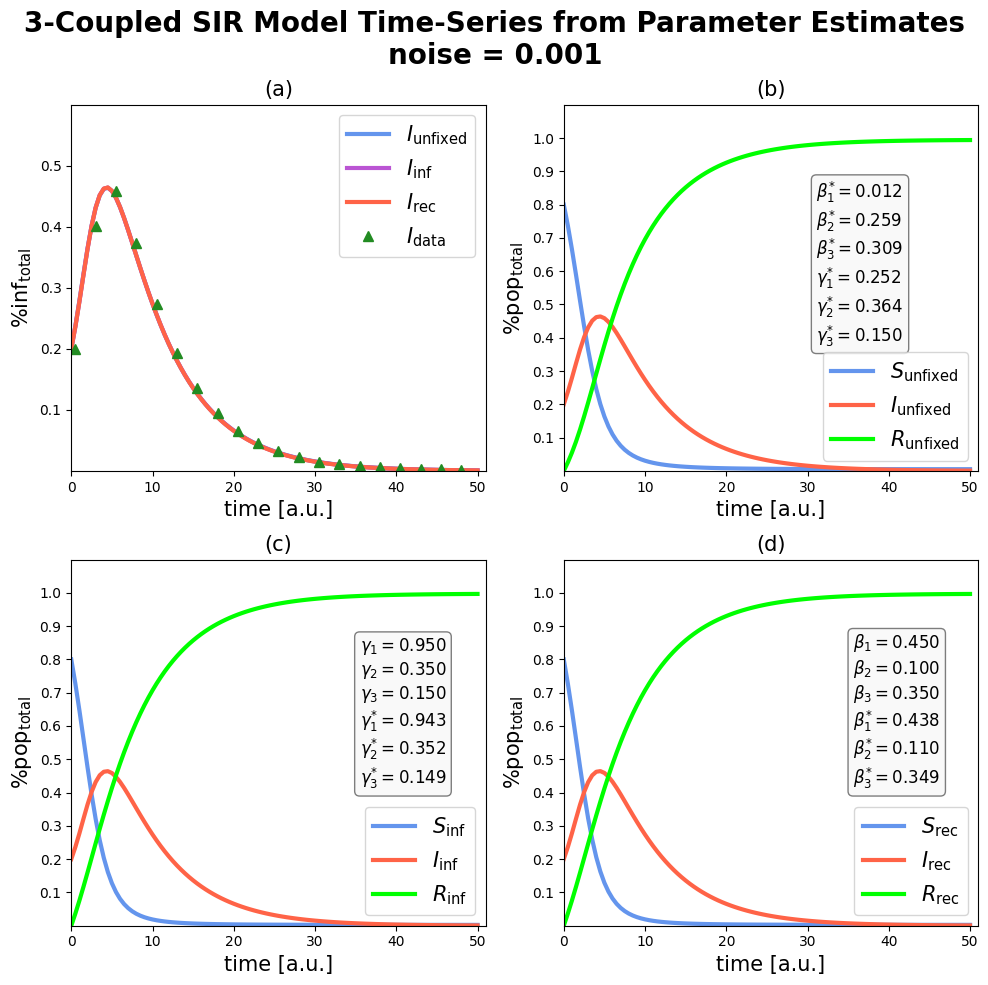

In [12]:

fig2, ax2 = plt.subplots(2,2, figsize = (10, 10))

# unfixed and fixed parameters
ax2[0,0].plot(t, unfixed_I_total, color = 'cornflowerblue', linewidth = 3, label = r'$I_{\text{unfixed}}$')
ax2[0,0].plot(t, fixed_inf_I_total, color = 'mediumorchid', linewidth = 3, label = r'$I_{\text{inf}}$')
ax2[0,0].plot(t, fixed_rec_I_total, color = 'tomato', linewidth = 3, label = r'$I_{\text{rec}}$')
ax2[0,0].plot(t_data, I_data, linestyle = ' ', marker = '^', markersize = 7, color = 'forestgreen', label = r'$I_{\text{data}}$')


ax2[0,0].legend(fontsize = 15)
ax2[0,0].set_xlabel("time [a.u.]", fontsize = 15)
ax2[0,0].set_ylabel(r"%$\text{inf}_{\text{total}}$", fontsize = 15)
ax2[0,0].set_ylim(0, .6)
ax2[0,0].set_xlim(t0, tf+1)
ax2[0,0].set_xticks(np.arange(t0, tf+1, 10))
ax2[0,0].set_yticks(np.arange(0.1, 0.6, 0.1))
ax2[0,0].set_title("(a)", fontsize = 15)


# unfixed 
ax2[0,1].plot(t, unfixed_S_total, color = 'cornflowerblue', linewidth = 3, label = r'$S_{\text{unfixed}}$')
ax2[0,1].plot(t, unfixed_I_total, color = 'tomato', linewidth = 3, label = r'$I_{\text{unfixed}}$')
ax2[0,1].plot(t, unfixed_R_total, color = 'lime', linewidth = 3, label = r'$R_{\text{unfixed}}$')

textstr = '\n'.join((r"$\beta_{1}^{*} = $%1.3f" %(unfixed_pstar[0]),
                     r"$\beta_{2}^{*} = $%1.3f" %(unfixed_pstar[1]),
                     r"$\beta_{3}^{*} = $%1.3f" %(unfixed_pstar[2]),
                     r"$\gamma_{1}^{*} = $%1.3f" %(unfixed_pstar[3]),
                     r"$\gamma_{2}^{*} = $%1.3f" %(unfixed_pstar[4]),
                     r"$\gamma_{3}^{*} = $%1.3f" %(unfixed_pstar[5]),
                     ))

props = dict(boxstyle='round', facecolor='whitesmoke', alpha=0.5)


leg1 = ax2[0,1].legend(fontsize = 15, loc = 'best')
tbbox = leg1.get_window_extent()
inv = plt.gca().transAxes.inverted()
x0, y0 = inv.transform((tbbox.x0, tbbox.y0))

ax2[0,1].text(x0+0.05, y0+0.05, s = textstr, bbox = props, fontsize = 12, transform = plt.gca().transAxes)

ax2[0,1].set_xlabel("time [a.u.]", fontsize = 15)
ax2[0,1].set_ylabel(r"%$\text{pop}_{\text{total}}$", fontsize = 15)
ax2[0,1].set_ylim(0, 1.1)
ax2[0,1].set_xlim(t0, tf+1)
ax2[0,1].set_xticks(np.arange(t0, tf+1, 10))
ax2[0,1].set_yticks(np.arange(0.1, 1.1, 0.1))
ax2[0,1].set_title("(b)", fontsize = 15)

# fixed infectivity
ax2[1,0].plot(t, fixed_inf_S_total, color = 'cornflowerblue', linewidth = 3, label = r'$S_{\text{inf}}$')
ax2[1,0].plot(t, fixed_inf_I_total, color = 'tomato', linewidth = 3, label = r'$I_{\text{inf}}$')
ax2[1,0].plot(t, fixed_inf_R_total, color = 'lime', linewidth = 3, label = r'$R_{\text{inf}}$')

textstr = '\n'.join((  r"$\gamma_{1} = $%1.3f" %(gamma1),
 r"$\gamma_{2} = $%1.3f" %(gamma2),
 r"$\gamma_{3} = $%1.3f" %(gamma3),
                     r"$\gamma_{1}^{*} = $%1.3f" %(fixed_inf_pstar[0]),
                     r"$\gamma_{2}^{*} = $%1.3f" %(fixed_inf_pstar[1]),
                     r"$\gamma_{3}^{*} = $%1.3f" %(fixed_inf_pstar[2]),
                     ))

props = dict(boxstyle='round', facecolor='whitesmoke', alpha=0.5)


leg2 = ax2[1,0].legend(fontsize = 15, loc = 'lower right')
tbbox = leg2.get_window_extent()
inv = plt.gca().transAxes.inverted()
x1, y1 = inv.transform((tbbox.x0, tbbox.y0))

ax2[1,0].text(x1+0.05, 13*y1, s = textstr, bbox = props, fontsize = 12, transform = plt.gca().transAxes)

ax2[1,0].set_xlabel("time [a.u.]", fontsize = 15)
ax2[1,0].set_ylabel(r"%$\text{pop}_{\text{total}}$", fontsize = 15)
ax2[1,0].set_ylim(0, 1.1)
ax2[1,0].set_xlim(t0, tf+1)
ax2[1,0].set_xticks(np.arange(t0, tf+1, 10))
ax2[1,0].set_yticks(np.arange(0.1, 1.1, 0.1))
ax2[1,0].set_title("(c)", fontsize = 15)


# fixed recovery
ax2[1,1].plot(t, fixed_rec_S_total, color = 'cornflowerblue', linewidth = 3, label = r'$S_{\text{rec}}$')
ax2[1,1].plot(t, fixed_rec_I_total, color = 'tomato', linewidth = 3, label = r'$I_{\text{rec}}$')
ax2[1,1].plot(t, fixed_rec_R_total, color = 'lime', linewidth = 3, label = r'$R_{\text{rec}}$')

textstr = '\n'.join((r"$\beta_{1} = $%1.3f" %(beta1),
r"$\beta_{2}= $%1.3f" %(beta2),
r"$\beta_{3} = $%1.3f" %(beta3),
                     r"$\beta_{1}^{*} = $%1.3f" %(fixed_rec_pstar[0]),
                     r"$\beta_{2}^{*} = $%1.3f" %(fixed_rec_pstar[1]),
                     r"$\beta_{3}^{*} = $%1.3f" %(fixed_rec_pstar[2]),
                     ))

props = dict(boxstyle='round', facecolor='whitesmoke', alpha=0.5)


leg3 = ax2[1,1].legend(fontsize = 15, loc = 'lower right')
tbbox = leg3.get_window_extent()
inv = plt.gca().transAxes.inverted()
x0, y0 = inv.transform((tbbox.x0, tbbox.y0))

ax2[1,1].text(x0+0.05, 13*y0, s = textstr, bbox = props, fontsize = 12, transform = plt.gca().transAxes)

ax2[1,1].set_xlabel("time [a.u.]", fontsize = 15)
ax2[1,1].set_ylabel(r"%$\text{pop}_{\text{total}}$", fontsize = 15)
ax2[1,1].set_ylim(0, 1.1)
ax2[1,1].set_xlim(t0, tf+1)
ax2[1,1].set_xticks(np.arange(t0, tf+1, 10))
ax2[1,1].set_yticks(np.arange(0.1, 1.1, 0.1))
ax2[1,1].set_title("(d)", fontsize = 15)

fig2.suptitle("3-Coupled SIR Model Time-Series from Parameter Estimates\nnoise = %1.3f" %(noise), fontsize = 20, fontweight = 'semibold')
fig2.tight_layout()

As expected, the fixed tests did produce an optimal $\mathbf{p}^*$ that was close to the actual parameters used to create the ideal data, even with the minimal noise level.
The unfixed test did match some of the parameter values, but others not as well:
\begin{align*}
\mathbf{p}_{\text{unfixed}}^{*}&=\begin{bmatrix}0.012\\0.259\\0.309\\0.252\\0.364\\0.150\end{bmatrix}, & \mathbf{p}&=\begin{bmatrix}0.450\\0.100\\0.3500\\0.950\\0.350\\0.150\end{bmatrix}.
\end{align*}
The overall geometry looks the same between the three curves too, which illuminates the pitfall more.
There are two distinct parameter vectors that produce total population time-series that are roughly the same.

## 3-Coupled SIR Model with Constant Subpopulation Size
The current 3-coupled model iteration features subpopulation migration, which from a physical standpoint doesn't make much sense.
Yes, there is definitely interaction between these subpopulations (which is precisely what we're modeling), but migrating between groups, when say these groups are schools in a school district, doesn't make much sense.
Also, the infectivity between subpopulation infections is the same.
That is, infection $I_1$ infects both $S_1, S_2, S_3$ with $\beta_1$, which implies the subpopulations are connected equally.

To get around this, we need a model with:
* Constant subpopulation size; and
* Different infectivities between subpopulations.

The model that accomplishes is
\begin{align*}
\dot{S}_{k} &= -\left(\sum_{i=1}^{3}\beta_{ki}I_{i}\right)S_{k}\\
\dot{I}_{k} &= \left(\sum_{i=1}^{3}\beta_{ki}I_{i}\right)S_{k} - \gamma_k I_k\\
\dot{R}_{k} &= \gamma_{k} I_k.
\end{align*}

The respective subpopulations have constant size $N_k=S_{k}+I_{k}+R_{k}$, and total population size is $N=\sum_{k=1}^{3}N_k$.
This model assumes that $S_k$ makes transmissive contact with $\beta_{ki} (N_{i}+S_{k})$ times throughout the duration of the infection, and the probability that an infective $I_i$ encounters a susepctible in subpopulation $k$ is $\frac{S_k}{N_i+S_{k}}$, when $i\not=k$.
Thus, the number of new infections caused by $I_i$ per unit time is $\beta_{ki}(N_i+S_{k})\left(\frac{S_k}{N_i+S_{k}}\right)I_i=\beta_{ki}S_{k}I_i$.
When $i=k$, then $S_k$ makes contact with $\beta_{kk}N_{k}$ infectives and the probability of infection is $\frac{S_{k}}{N_{k}}$, and thus, the number of new infections caused by $I_k$ is $\beta_{kk}S_{k}I_{k}$.


In [13]:
# =============================================================================
# constant subpopulation size 3-coupled model
# =============================================================================

def SIR_3_const_subpop(t, S, p):
    
    s1, i1, r1, s2, i2, r2, s3, i3, r3 = S
    
    p11, p12, p13, p14, p21, p22, p23, p24, p31, p32, p33, p34 = p
    
    return np.array([-(p11*i1 + p12*i2 + p13*i3)*(s1),
                     (p11*i1 + p12*i2 + p13*i3)*(s1)-p14*i1,
                     p14*i1,
                     
                     -(p21*i1 + p22*i2 + p23*i3)*(s2),
                     (p21*i1 + p22*i2 + p23*i3)*(s2)-p24*i2,
                     p24*i2,
                     
                     -(p31*i1 + p32*i2 + p33*i3)*(s3),
                     (p31*i1 + p32*i2 + p33*i3)*(s3)-p34*i3,
                     p34*i3,
                     
                     ])

# setting initial parameters
s10 = 0.9
s20 = 0.8
s30 = 0.7

i10 = 1 - s10
i20 = 1 - s20
i30 = 1 - s30

r10 = 0.
r20 = 0.
r30 = 0.

S0 = np.array([s10, i10, r10, 
               s20, i20, r20,
               s30, i30, r30])


t0 = 0
tf = 50

n = 5000

# infectivity and recovery rates, respectively
beta11 = 0.25
beta12 = 0.10
beta13 = 0.22

beta21 = 0.35
beta22 = 0.15
beta23 = 0.25

beta31 = 0.75
beta32 = 0.05
beta33 = 0.05

gamma1 = 1.00
gamma2 = 0.35
gamma3 = 0.15

p = np.array([beta11, beta12, beta13, gamma1,
              beta21, beta22, beta23, gamma2,
              beta31, beta32, beta33, gamma3])





t, S_cp = RK4_sys(t0, tf, n, S0, SIR_3_const_subpop, p)

S_total_cp = np.sum(S_cp[0:-1:3, :], axis = 0)/3
I_total_cp = np.sum(S_cp[1:-1:3, :], axis = 0)/3
R_total_cp = np.sum(S_cp[2:9:3, :], axis = 0)/3


S1_cp = S_cp[0, :]
I1_cp = S_cp[1, :]
R1_cp = S_cp[2, :]

S2_cp = S_cp[3, :]
I2_cp = S_cp[4, :]
R2_cp = S_cp[5, :]

S3_cp = S_cp[6, :]
I3_cp = S_cp[7, :]
R3_cp = S_cp[8, :] 


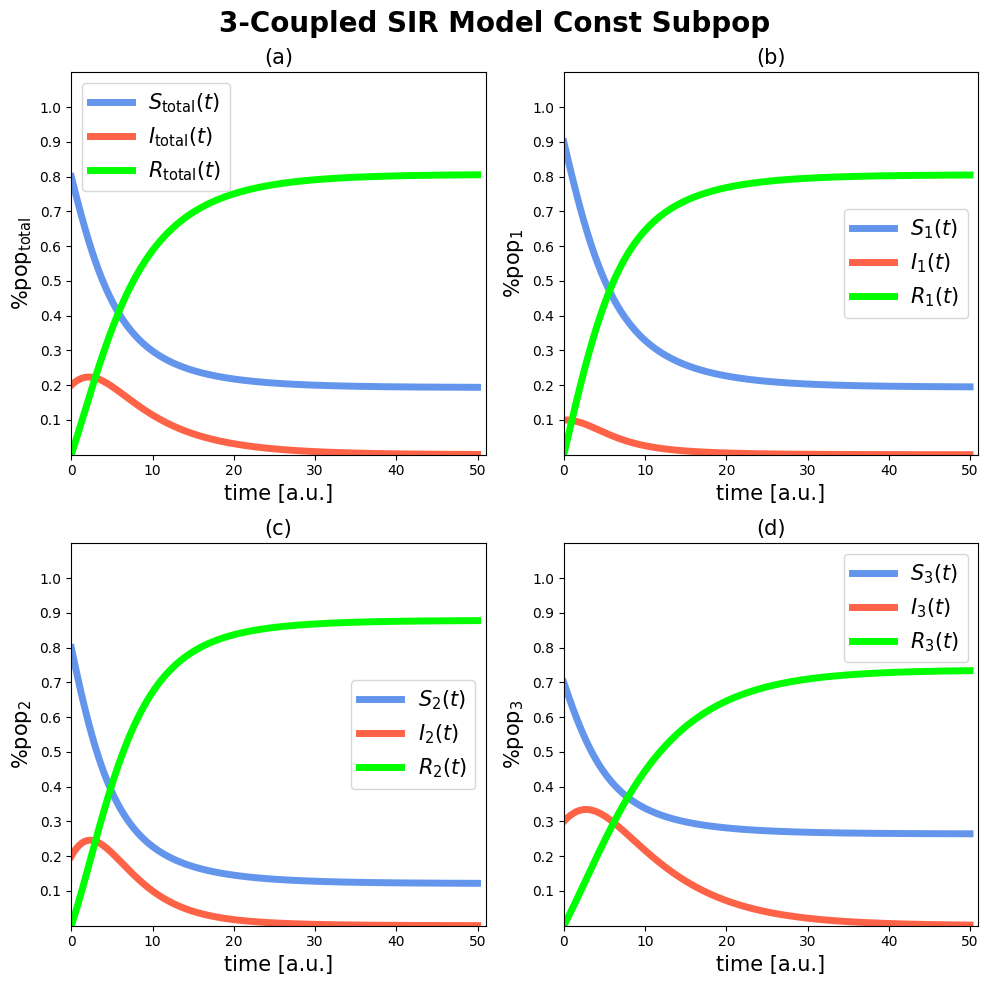

In [14]:
fig3, ax3 = plt.subplots(2,2, figsize = (10,10))
ax3[0,0].plot(t, S_total_cp, color = 'cornflowerblue', label = r'$S_{\text{total}}(t)$', linewidth = 5)
ax3[0,0].plot(t,I_total_cp, color = 'tomato', label = r'$I_{\text{total}}(t)$', linewidth = 5)
ax3[0,0].plot(t,R_total_cp, color = 'lime', label = r'$R_{\text{total}}(t)$', linewidth = 5)
ax3[0,0].legend(fontsize = 15)
ax3[0,0].set_xlabel("time [a.u.]", fontsize = 15)
ax3[0,0].set_ylabel(r"%$\text{pop}_{\text{total}}$", fontsize = 15)
ax3[0,0].set_ylim(0, 1.1)
ax3[0,0].set_xlim(t0, tf+1)
ax3[0,0].set_xticks(np.arange(t0, tf+1, 10))
ax3[0,0].set_yticks(np.arange(0.1, 1.1, 0.1))
ax3[0,0].set_title("(a)", fontsize = 15)

ax3[0,1].plot(t, S1_cp, color = 'cornflowerblue', label = r'$S_{1}(t)$', linewidth = 5)
ax3[0,1].plot(t,I1_cp, color = 'tomato', label = r'$I_{1}(t)$', linewidth = 5)
ax3[0,1].plot(t,R1_cp, color = 'lime', label = r'$R_{1}(t)$', linewidth = 5)
ax3[0,1].legend(fontsize = 15)
ax3[0,1].set_xlabel("time [a.u.]", fontsize = 15)
ax3[0,1].set_ylabel(r"%$\text{pop}_{1}$", fontsize = 15)
ax3[0,1].set_ylim(0, 1.1)
ax3[0,1].set_xlim(t0, tf+1)
ax3[0,1].set_xticks(np.arange(t0, tf+1, 10))
ax3[0,1].set_yticks(np.arange(0.1, 1.1, 0.1))
ax3[0,1].set_title("(b)", fontsize = 15)

ax3[1,0].plot(t, S2_cp, color = 'cornflowerblue', label = r'$S_{2}(t)$', linewidth = 5)
ax3[1,0].plot(t,I2_cp, color = 'tomato', label = r'$I_{2}(t)$', linewidth = 5)
ax3[1,0].plot(t,R2_cp, color = 'lime', label = r'$R_{2}(t)$', linewidth = 5)
ax3[1,0].legend(fontsize = 15)
ax3[1,0].set_xlabel("time [a.u.]", fontsize = 15)
ax3[1,0].set_ylabel(r"%$\text{pop}_{2}$", fontsize = 15)
ax3[1,0].set_ylim(0, 1.1)
ax3[1,0].set_xlim(t0, tf+1)
ax3[1,0].set_xticks(np.arange(t0, tf+1, 10))
ax3[1,0].set_yticks(np.arange(0.1, 1.1, 0.1))
ax3[1,0].set_title("(c)", fontsize = 15)

ax3[1,1].plot(t, S3_cp, color = 'cornflowerblue', label = r'$S_{3}(t)$', linewidth = 5)
ax3[1,1].plot(t, I3_cp, color = 'tomato', label = r'$I_{3}(t)$', linewidth = 5)
ax3[1,1].plot(t, R3_cp, color = 'lime', label = r'$R_{3}(t)$', linewidth = 5)
ax3[1,1].legend(fontsize = 15)
ax3[1,1].set_xlabel("time [a.u.]", fontsize = 15)
ax3[1,1].set_ylabel(r"%$\text{pop}_{3}$", fontsize = 15)
ax3[1,1].set_ylim(0, 1.1)
ax3[1,1].set_xlim(t0, tf+1)
ax3[1,1].set_xticks(np.arange(t0, tf+1, 10))
ax3[1,1].set_yticks(np.arange(0.1, 1.1, 0.1))
ax3[1,1].set_title("(d)", fontsize = 15)
fig3.suptitle("3-Coupled SIR Model Const Subpop", fontweight = 'semibold', fontsize = 20)
fig3.tight_layout()


## Epidemiological Analysis of 3-coupled SIR Model
The fundamental quantity in mathematical epidemiology is the basic reproduction number $\mathrm{R}_0$, which has the physical interpretation as the number of secondary infections caused by a typical infective throughout the duration of their infection.
That is, the number of people that get infected from one infected person.
It serves as a threshold quantity, in that if $\mathrm{R}_0>1$, then an epidemic will occur, and when $\mathrm{R}_0<1$, no epidemic will happen.
It also serves a way of quantifying how infective a particular disease is.
Measles happens to be the most infectious disease with a basic reproduction number ranging from $12$-$18$, meaning that one infected person will infect anywhere from $12$ to $18$ other individuals.

One curiousity I have with this model is if two subpopulations with $\mathrm{R}_0<1$, but the third with $\mathrm{R}_0>1$, will there be an epidemic in the total population?
Specifically, what level of connectivity between the subpopulations will result in a total population epidemic?
